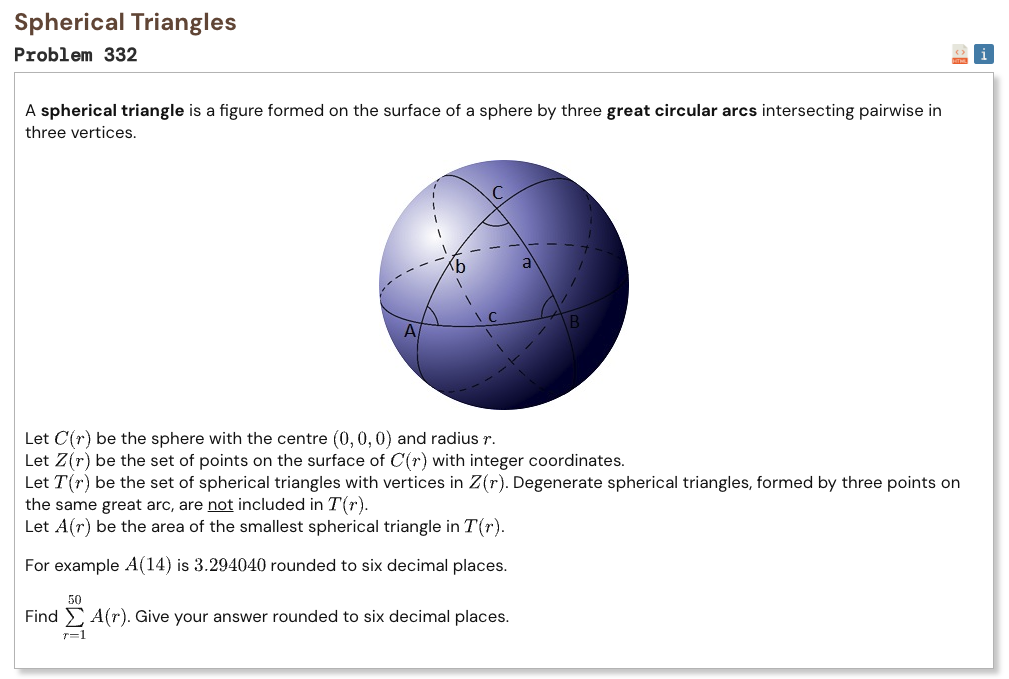

## Initial approach

* generate all integer points on each sphere
* try every non-degenerate triangle made from those points
* use a stable spherical-area calculation based on vectors
* skip triples that lie on the same great circle
* keep the smallest area for each radius
* add the smallest areas from radius 1 to 50
* round the final sum to six decimal places

In [1]:
import math

def integer_points_on_sphere(r):
    points = []
    rr = r * r

    for x in range(-r, r + 1):
        for y in range(-r, r + 1):
            z2 = rr - x * x - y * y

            if z2 < 0:
                continue

            z = math.isqrt(z2)

            if z * z == z2:
                if z == 0:
                    points.append((x, y, 0))
                else:
                    points.append((x, y, z))
                    points.append((x, y, -z))

    return points

def dot(a, b):
    return a[0] * b[0] + a[1] * b[1] + a[2] * b[2]

def cross(a, b):
    return (
        a[1] * b[2] - a[2] * b[1],
        a[2] * b[0] - a[0] * b[2],
        a[0] * b[1] - a[1] * b[0]
    )

def spherical_area(a, b, c, r):
    ab_cross = cross(a, b)
    det = abs(dot(ab_cross, c))

    if det == 0:
        return None

    denominator = r ** 3 + r * (dot(a, b) + dot(b, c) + dot(c, a))
    return 2 * r * r * math.atan2(det, denominator)

def minimum_area_for_radius(r):
    points = integer_points_on_sphere(r)
    best = float("inf")
    n = len(points)

    for i in range(n):
        a = points[i]

        for j in range(i + 1, n):
            b = points[j]
            ab_cross = cross(a, b)
            ab_dot = dot(a, b)

            for k in range(j + 1, n):
                c = points[k]
                det = abs(dot(ab_cross, c))

                if det == 0:
                    continue

                denominator = r ** 3 + r * (ab_dot + dot(b, c) + dot(c, a))
                area = 2 * r * r * math.atan2(det, denominator)

                if area < best:
                    best = area

    return best

def solve():
    total = 0.0

    for r in range(1, 51):
        total += minimum_area_for_radius(r)

    return total

In [2]:
%%time
result = solve()
print("Result:", f"{result:.6f}")

Result: 2717.751525
CPU times: user 42.5 s, sys: 134 ms, total: 42.6 s
Wall time: 43.2 s
